# FINAL PROJECT - IRONHACK - MARCH 2026

Table of Content 

1. First step
2. Second step
3. Third step


In [1]:
#setup with all imports

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#formatting 
pd.options.display.float_format="{:,.2f}".format
pd.options.display.max_columns=None


+++ 

In [2]:
#Initial Setup and Review of Data Set 
 
#get all the data sets

customers = pd.read_csv("/Users/Julian/Desktop/IronHack/Final-Project/Data/Raw/olist_customers_dataset.csv")
order_items = pd.read_csv("/Users/Julian/Desktop/IronHack/Final-Project/Data/Raw/olist_order_items_dataset.csv")
order_payments = pd.read_csv("/Users/Julian/Desktop/IronHack/Final-Project/Data/Raw/olist_order_payments_dataset.csv")
order_reviews = pd.read_csv("/Users/Julian/Desktop/IronHack/Final-Project/Data/Raw/olist_order_reviews_dataset.csv")
products = pd.read_csv("/Users/Julian/Desktop/IronHack/Final-Project/Data/Raw/olist_products_dataset.csv")
sellers = pd.read_csv("/Users/Julian/Desktop/IronHack/Final-Project/Data/Raw/olist_sellers_dataset.csv")
category_translation = pd.read_csv("/Users/Julian/Desktop/IronHack/Final-Project/Data/Raw/product_category_name_translation.csv")


orders = pd.read_csv("/Users/Julian/Desktop/IronHack/Final-Project/Data/Raw/olist_orders_dataset.csv")
geolocation = pd.read_csv("/Users/Julian/Desktop/IronHack/Final-Project/Data/Raw/olist_geolocation_dataset.csv")


#develop a master df

df = (orders
      .merge(customers, on='customer_id', how='left')
      .merge(order_items, on='order_id', how='left')
      .merge(order_payments, on='order_id', how='left')
      .merge(order_reviews, on='order_id', how='left')
      .merge(products, on='product_id', how='left')
      .merge(sellers, on='seller_id', how='left')
      .merge(category_translation, on='product_category_name', how='left')
     )

#converting datetime as it is str

# Convert datetime columns inside df
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col])


# Convert datetime columns
date_cols = ['order_purchase_timestamp', 'order_approved_at', 
             'order_delivered_carrier_date', 'order_delivered_customer_date',
             'order_estimated_delivery_date']
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

#get some info on this data set

print(f"✅ Master dataframe: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"📦 Orders: {orders.shape[0]:,}")
print(f"👥 Unique Customers: {customers['customer_unique_id'].nunique():,}")
print(f"🏪 Unique Sellers: {sellers['seller_id'].nunique():,}")
print(f"⏰ Date Range: {orders['order_purchase_timestamp'].min().date()} → {orders['order_purchase_timestamp'].max().date()}")


✅ Master dataframe: 119,143 rows × 40 columns
📦 Orders: 99,441
👥 Unique Customers: 96,096
🏪 Unique Sellers: 3,095
⏰ Date Range: 2016-09-04 → 2018-10-17


++++ NEW AND REPEAT CUSTOMR 

In [4]:
# 📊 Count of NEW & REPEAT customer  
# ==============================


#clean the dataset as duplicates exist for orders (why? mergered order_ietms and order_paymetns, have dupliacte rows per order (1 per item and payment installment)

# Keep only unique customer-order combinations
orders_clean = df[['customer_unique_id', 
                   'order_id', 
                   'order_purchase_timestamp',
                   'payment_value']].drop_duplicates()

#correcting the date-time
orders_clean['order_purchase_timestamp'] = pd.to_datetime(
    orders_clean['order_purchase_timestamp'])


customer_orders = (
    orders_clean
    .groupby('customer_unique_id')['order_id']
    .nunique()
    .reset_index()
    .rename(columns={'order_id': 'total_orders'})
)

customer_orders['customer_type'] = customer_orders['total_orders'].apply(
    lambda x: 'Repeat' if x > 1 else 'New'
)




# ==============================
# 📊 #Revenue New and Repeat 
# ==============================


# First aggregate revenue per order
order_revenue = (
    orders_clean
    .groupby(['customer_unique_id', 'order_id'])['payment_value']
    .sum()
    .reset_index()
)

# Then aggregate per customer
customer_revenue = (
    order_revenue
    .groupby('customer_unique_id')['payment_value']
    .sum()
    .reset_index()
)

# Merge with customer type
customer_analysis = customer_orders.merge(customer_revenue, 
                                          on='customer_unique_id')





print(f"👥 Customers: {customer_orders['customer_type'].value_counts()}")
print("\n")
print(f"👥 Customers AVG Revenue: {customer_analysis.groupby('customer_type')['payment_value'].mean()}")
print("\n")
print(f"👥 Customers TOTAL Revenue: {customer_analysis.groupby('customer_type')['payment_value'].sum()}")


👥 Customers: customer_type
New       93099
Repeat     2997
Name: count, dtype: int64


👥 Customers AVG Revenue: customer_type
New      161.64
Repeat   314.41
Name: payment_value, dtype: float64


👥 Customers TOTAL Revenue: customer_type
New      15,048,703.22
Repeat      942,299.62
Name: payment_value, dtype: float64


<Axes: xlabel='cohort_month'>

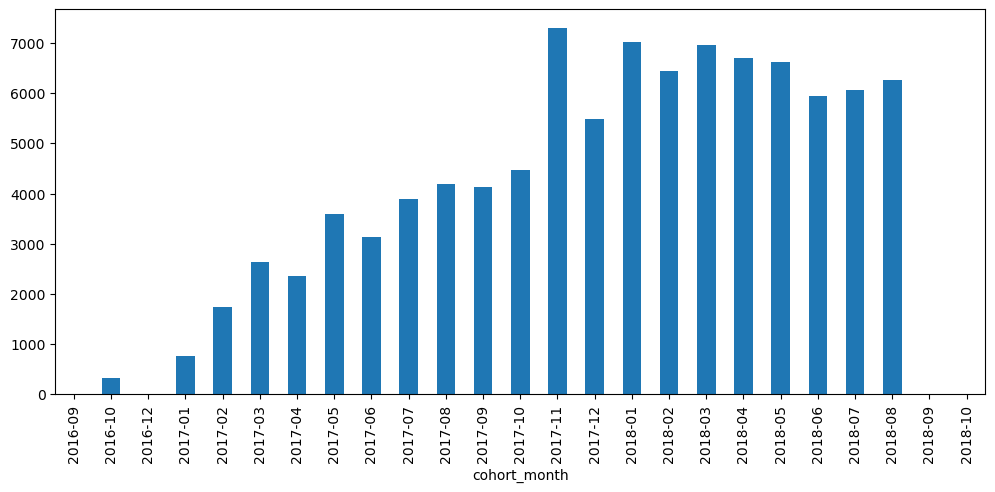

In [6]:
#Acqusition Trend Analysis 

first_purchase = (
    orders_clean
    .groupby('customer_unique_id')['order_purchase_timestamp']
    .min()
    .reset_index()
)

first_purchase['cohort_month'] = first_purchase['order_purchase_timestamp'].dt.to_period('M')

new_customers_by_month = first_purchase.groupby('cohort_month').size()

new_customers_by_month.plot(kind='bar', figsize=(12,5))

In [6]:
### Comvert to CSV file 

#customer_analysis.to_csv(
#    "/Users/Julian/Desktop/IronHack/Final-Project/Data/Clean/customer_analysis.csv",
#    index=False,
#    encoding="utf-8"
#)

print("File saved successfully ✅")

File saved successfully ✅


#### DEVELOPING AN RFM SEGMENTATION 

In [7]:
# 📊 Building RFM segments 
# ==============================

#Selecting Data Points and Cleaning Data Set & Building RFM segments 

# Keep only relevant columns
rfm_df = df[['customer_unique_id',
             'order_id',
             'order_purchase_timestamp',
             'payment_value']].copy()

# Ensure datetime
rfm_df['order_purchase_timestamp'] = pd.to_datetime(rfm_df['order_purchase_timestamp'])

# Aggregate revenue per order (important because of duplicates)
rfm_df = (
    rfm_df
    .groupby(['customer_unique_id', 'order_id', 'order_purchase_timestamp'])['payment_value']
    .sum()
    .reset_index()
)

snapshot_date = rfm_df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

#Setting up RFM DataFrame with relevant R-F_M coloums 
rfm = rfm_df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days,
    'order_id': 'nunique',
    'payment_value': 'sum'
}).reset_index()

rfm.columns = ['customer_unique_id', 'Recency', 'Frequency', 'Monetary']

#Developing the Model 
## important note:
## 555 --> best customer 
## 111 --> worst customer 


rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1]).astype(int)
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5]).astype(int)

rfm['RFM_Score'] = (
    rfm['R_score'].astype(str) + 
    rfm['F_score'].astype(str) + 
    rfm['M_score'].astype(str)
)



#Buliding the segments HV vs. LV ones
def segment_customer(row):
    if row['R_score'] == 5 and row['F_score'] == 5 and row['M_score'] == 5:
        return 'Champions'
    elif row['R_score'] >= 4 and row['F_score'] >= 4:
        return 'Loyal Customers'
    elif row['R_score'] >= 4:
        return 'Recent Customers'
    elif row['F_score'] >= 4:
        return 'Frequent Customers'
    elif row['M_score'] >= 4:
        return 'Big Spenders'
    else:
        return 'Others'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)


print(f"👥 RFM Segments - % Breakdown: {rfm['Segment'].value_counts(normalize=True) * 100}")
print("\n")
print(f"👥 RFM Segments - Revenue: {rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)}")


👥 RFM Segments - % Breakdown: Segment
Recent Customers     24.11
Frequent Customers   23.92
Others               22.21
Loyal Customers      15.03
Big Spenders         13.68
Champions             1.05
Name: proportion, dtype: float64


👥 RFM Segments - Revenue: Segment
Big Spenders         5,513,401.27
Frequent Customers   5,011,465.65
Recent Customers     4,779,557.01
Loyal Customers      2,954,326.04
Others               1,597,091.38
Champions              723,822.66
Name: Monetary, dtype: float64


In [8]:
### Comvert to CSV file 

#rfm.to_csv(
#    "/Users/Julian/Desktop/IronHack/Final-Project/Data/Clean/rfm.csv",
#    index=False,
#    encoding="utf-8"
#)
#
print("File saved successfully ✅")

File saved successfully ✅


+++ CLV 

In [8]:
# 📊 CVL - Historical & Predictive
# ==============================


#step 1 : customer lifespan 

customer_lifespan = (
    rfm_df
    .groupby('customer_unique_id')['order_purchase_timestamp']
    .agg(['min','max'])
    .reset_index()
)

customer_lifespan['lifespan_days'] = (
    customer_lifespan['max'] - customer_lifespan['min']
).dt.days

# Step 2: Calculate Average order vlaue
aov = (
    rfm_df
    .groupby('customer_unique_id')['payment_value']
    .mean()
    .reset_index()
    .rename(columns={'payment_value': 'avg_order_value'})
)

#Step 3: lets merge everything 
clv = rfm.merge(aov, on='customer_unique_id')
clv = clv.merge(customer_lifespan[['customer_unique_id','lifespan_days']],
                on='customer_unique_id')

#Step 4: Estimate CLV 

#simple version 
clv['CLV'] = clv['avg_order_value'] * clv['Frequency']


#advance version
clv['purchase_frequency_rate'] = clv['Frequency'] / clv['lifespan_days'].replace(0,1)

clv['CLV_advanced'] = (
    clv['avg_order_value'] *
    clv['purchase_frequency_rate'] *
    365
)



In [10]:
### Comvert to CSV file 

#clv.to_csv(
#    "/Users/Julian/Desktop/IronHack/Final-Project/Data/Clean/clv.csv",
#    index=False,
#    encoding="utf-8"
#)

print("File saved successfully ✅")


File saved successfully ✅


In [9]:
# 📊 RFM + CLV SEGMENT ANALYSIS & INSIGHTS
# ==============================



# 1️⃣ Segment Distribution (% of Customers)
segment_pct = clv['Segment'].value_counts(normalize=True) * 100

print("👥 RFM Segments - % Breakdown:")
print(segment_pct.round(2))
print("\n")


# 2️⃣ Total Revenue by Segment
segment_revenue = (
    clv.groupby('Segment')['Monetary']
    .sum()
    .sort_values(ascending=False)
)

print("💰 RFM Segments - Total Revenue:")
print(segment_revenue.round(2))
print("\n")


# 3️⃣ Revenue Share by Segment (%)
total_revenue = clv['Monetary'].sum()

revenue_share = (
    clv.groupby('Segment')['Monetary']
    .sum() / total_revenue * 100
).sort_values(ascending=False)

print("🏆 Revenue Share by Segment (%):")
print(revenue_share.round(2))
print("\n")


# 4️⃣ Average Historical CLV by Segment
segment_clv = (
    clv.groupby('Segment')['CLV']
    .mean()
    .sort_values(ascending=False)
)

print("📈 Avg Historical CLV by Segment:")
print(segment_clv.round(2))
print("\n")


# 5️⃣ Average Advanced CLV by Segment
segment_clv_adv = (
    clv.groupby('Segment')['CLV_advanced']
    .mean()
    .sort_values(ascending=False)
)

print("🚀 Avg Advanced CLV by Segment:")
print(segment_clv_adv.round(2))
print("\n")


# 6️⃣ Behavioral Metrics by Segment
segment_behavior = (
    clv.groupby('Segment')
    .agg({
        'Frequency': 'mean',
        'Recency': 'mean',
        'avg_order_value': 'mean',
        'purchase_frequency_rate': 'mean'
    })
    .round(2)
)

print("📊 Behavioral Metrics by Segment:")
print(segment_behavior)
print("\n")


# 7️⃣ High-Potential Customers (High CLV_advanced + Recent Customers)
high_potential = clv[
    (clv['CLV_advanced'] > clv['CLV_advanced'].median()) &
    (clv['Segment'] == "Recent Customers")
]

print(f"🎯 High Potential Customers Count: {len(high_potential)}")
print("\n")

print("✅ RFM + CLV Analysis Complete")

👥 RFM Segments - % Breakdown:
Segment
Recent Customers     24.11
Frequent Customers   23.92
Others               22.21
Loyal Customers      15.03
Big Spenders         13.68
Champions             1.05
Name: proportion, dtype: float64


💰 RFM Segments - Total Revenue:
Segment
Big Spenders         5,513,401.27
Frequent Customers   5,011,465.65
Recent Customers     4,779,557.01
Loyal Customers      2,954,326.04
Others               1,597,091.38
Champions              723,822.66
Name: Monetary, dtype: float64


🏆 Revenue Share by Segment (%):
Segment
Big Spenders         26.79
Frequent Customers   24.35
Recent Customers     23.22
Loyal Customers      14.36
Others                7.76
Champions             3.52
Name: Monetary, dtype: float64


📈 Avg Historical CLV by Segment:
Segment
Champions            719.51
Big Spenders         419.46
Frequent Customers   218.03
Recent Customers     206.28
Loyal Customers      204.49
Others                74.83
Name: CLV, dtype: float64


🚀 Avg Advanced C

+++ CHURN MODEL PIPELINE

In [10]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from imblearn.over_sampling import SMOTE

In [11]:
# Ensure datetime
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

# Last purchase per customer
last_purchase = (
    df.groupby('customer_unique_id')['order_purchase_timestamp']
    .max()
    .reset_index()
    .rename(columns={'order_purchase_timestamp': 'last_purchase_date'})
)

# Dataset end date
dataset_end = df['order_purchase_timestamp'].max()

# Days since last purchase
last_purchase['days_since_last_purchase'] = (
    dataset_end - last_purchase['last_purchase_date']
).dt.days

# Churn definition
churn_threshold = 90

last_purchase['churn'] = np.where(
    last_purchase['days_since_last_purchase'] > churn_threshold,
    1, 0
)

print("Churn rate:")
print(last_purchase['churn'].value_counts(normalize=True))

Churn rate:
churn
1   0.90
0   0.10
Name: proportion, dtype: float64


In [12]:
customer_features = df.groupby('customer_unique_id').agg({
    'order_id': 'nunique',
    'payment_value': ['sum', 'mean'],
    'review_score': 'mean',
    'product_id': 'nunique',
    'seller_id': 'nunique'
})

customer_features.columns = [
    'frequency',
    'monetary_total',
    'avg_order_value',
    'avg_review_score',
    'product_diversity',
    'seller_diversity'
]

# Recency (relative to dataset end)
last_purchase_dates = (
    df.groupby('customer_unique_id')['order_purchase_timestamp']
    .max()
)

customer_features['recency'] = (
    dataset_end - last_purchase_dates
).dt.days

customer_features = customer_features.reset_index()

In [13]:
customer_features = customer_features.merge(
    last_purchase[['customer_unique_id', 'churn']],
    on='customer_unique_id',
    how='left'
)

print("Final churn rate:")
print(customer_features['churn'].value_counts(normalize=True))

Final churn rate:
churn
1   0.90
0   0.10
Name: proportion, dtype: float64


In [14]:
# TRAIN THE MODEL 
# -----------------------------


X = customer_features.drop(['customer_unique_id', 'churn', 'recency'], axis=1) #removed recency as it took over the entire model 
y = customer_features['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=0,
    stratify=y
)

In [15]:
# 1️⃣ MODEL 1 - LOGISTICS REGRESSION (BASELINE) 
# -----------------------------


log_model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # used to fix NaN
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced', max_iter=1000))
])

log_model.fit(X_train, y_train)

log_probs = log_model.predict_proba(X_test)[:,1]

print("Logistic ROC-AUC:", roc_auc_score(y_test, log_probs))
print("Logistic PR-AUC:", average_precision_score(y_test, log_probs))



Logistic ROC-AUC: 0.5369351794995243
Logistic PR-AUC: 0.9112571016169501


In [16]:
# 2️⃣ MODEL 2 - RANDOM FOREST 
# -----------------------------


rf_model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        class_weight='balanced',
        random_state=0
    ))
])

rf_model.fit(X_train, y_train)

rf_probs = rf_model.predict_proba(X_test)[:,1]

print("RF ROC-AUC:", roc_auc_score(y_test, rf_probs))
print("RF PR-AUC:", average_precision_score(y_test, rf_probs))




RF ROC-AUC: 0.5749875859515556
RF PR-AUC: 0.9190822880362732


In [17]:
# 3️⃣  MODEL 3 - SMOTE
# -----------------------------

from imblearn.pipeline import Pipeline as ImbPipeline


smote_model = ImbPipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('smote', SMOTE(random_state=0)),
    ('model', RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        random_state=0
    ))
])

smote_model.fit(X_train, y_train)

smote_probs = smote_model.predict_proba(X_test)[:,1]

print("SMOTE ROC-AUC:", roc_auc_score(y_test, smote_probs))
print("SMOTE PR-AUC:", average_precision_score(y_test, smote_probs))






/opt/miniconda3/envs/data-analytics/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


SMOTE ROC-AUC: 0.5452826600948396
SMOTE PR-AUC: 0.9129908866433166


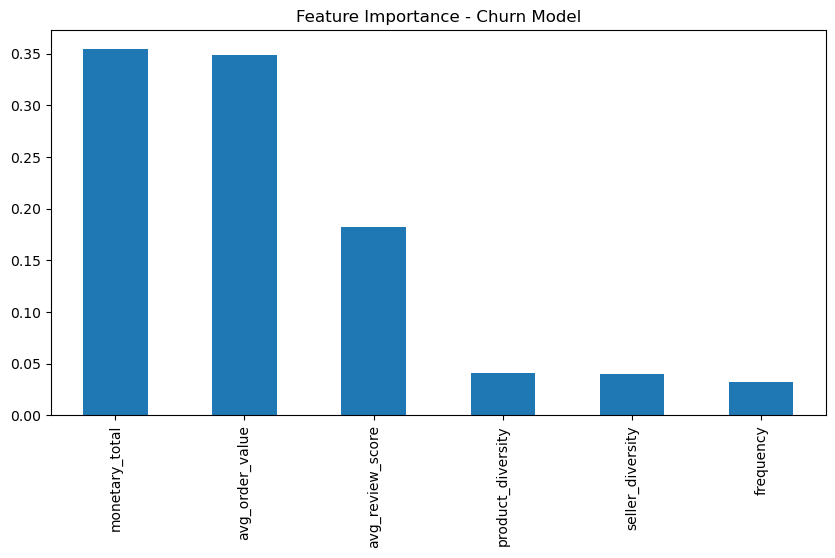

In [18]:
### FEATURE IMPORTANCE



feature_names = X.columns
importances = rf_model.named_steps['model'].feature_importances_

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

feat_imp.plot(kind='bar', figsize=(10,5))
plt.title("Feature Importance - Churn Model")
plt.show()

+++ Advance Feature ENgineering 

In [ ]:
# 🔥 ADVANCED FEATURE ENGINEERING FOR CHURN
# =====================================================

import numpy as np

df = df.sort_values(['customer_unique_id', 'order_purchase_timestamp'])

# -----------------------------------------------------
# 1️⃣ Interpurchase Time Features
# -----------------------------------------------------

df['prev_purchase'] = df.groupby('customer_unique_id')['order_purchase_timestamp'].shift()

df['days_between_orders'] = (
    df['order_purchase_timestamp'] - df['prev_purchase']
).dt.days

interpurchase = df.groupby('customer_unique_id').agg({
    'days_between_orders': ['mean', 'std', 'max', 'min']
})

interpurchase.columns = [
    'avg_days_between_orders',
    'std_days_between_orders',
    'max_days_between_orders',
    'min_days_between_orders'
]

# -----------------------------------------------------
# 2️⃣ Customer Lifetime Features
# -----------------------------------------------------

customer_lifetime = df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': ['min', 'max']
})

customer_lifetime.columns = ['first_purchase', 'last_purchase']

customer_lifetime['customer_lifetime_days'] = (
    customer_lifetime['last_purchase'] - customer_lifetime['first_purchase']
).dt.days

# -----------------------------------------------------
# 3️⃣ Order Acceleration (Are purchases speeding up?)
# -----------------------------------------------------

acceleration = df.groupby('customer_unique_id')['days_between_orders'].mean().reset_index()
acceleration.columns = ['customer_unique_id', 'avg_days_between_orders']

# -----------------------------------------------------
# 4️⃣ Purchase Intensity
# -----------------------------------------------------

purchase_counts = df.groupby('customer_unique_id')['order_id'].nunique()

purchase_intensity = (
    purchase_counts / (customer_lifetime['customer_lifetime_days'].replace(0,1))
)

purchase_intensity = purchase_intensity.reset_index()
purchase_intensity.columns = ['customer_unique_id', 'purchase_intensity']

# -----------------------------------------------------
# 5️⃣ Installment Behavior
# -----------------------------------------------------

installments = df.groupby('customer_unique_id')['payment_installments'].mean().reset_index()
installments.columns = ['customer_unique_id', 'avg_installments']

# -----------------------------------------------------
# 6️⃣ Delivery Delay Behavior
# -----------------------------------------------------

df['delivery_delay'] = (
    df['order_delivered_customer_date'] - df['order_estimated_delivery_date']
).dt.days

delivery_behavior = df.groupby('customer_unique_id')['delivery_delay'].mean().reset_index()
delivery_behavior.columns = ['customer_unique_id', 'avg_delivery_delay']

# -----------------------------------------------------
# 7️⃣ Merge All New Features
# -----------------------------------------------------

customer_features = customer_features.merge(
    interpurchase.reset_index(), on='customer_unique_id', how='left'
)

customer_features = customer_features.merge(
    customer_lifetime[['customer_lifetime_days']].reset_index(),
    on='customer_unique_id', how='left'
)

customer_features = customer_features.merge(
    purchase_intensity, on='customer_unique_id', how='left'
)

customer_features = customer_features.merge(
    installments, on='customer_unique_id', how='left'
)

customer_features = customer_features.merge(
    delivery_behavior, on='customer_unique_id', how='left'
)

# Replace infinities and NaNs
customer_features = customer_features.replace([np.inf, -np.inf], np.nan)

In [20]:
# TRAIN THE MODEL 
# -----------------------------


X = customer_features.drop(['customer_unique_id', 'churn', 'recency'], axis=1) #removed recency as it took over the entire model 
y = customer_features['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=0,
    stratify=y
)

In [21]:
# 1️⃣ MODEL 1 - LOGISTICS REGRESSION (BASELINE) 
# -----------------------------


log_model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # used to fix NaN
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced', max_iter=1000))
])

log_model.fit(X_train, y_train)

log_probs = log_model.predict_proba(X_test)[:,1]

print("Logistic ROC-AUC:", roc_auc_score(y_test, log_probs))
print("Logistic PR-AUC:", average_precision_score(y_test, log_probs))



Logistic ROC-AUC: 0.6571648010156641
Logistic PR-AUC: 0.9371819642801382


In [22]:
# 2️⃣ MODEL 2 - RANDOM FOREST 
# -----------------------------


rf_model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        class_weight='balanced',
        random_state=0
    ))
])

rf_model.fit(X_train, y_train)

rf_probs = rf_model.predict_proba(X_test)[:,1]

print("RF ROC-AUC:", roc_auc_score(y_test, rf_probs))
print("RF PR-AUC:", average_precision_score(y_test, rf_probs))




RF ROC-AUC: 0.7038994551405084
RF PR-AUC: 0.9461388687996003


In [23]:
# 3️⃣  MODEL 3 - SMOTE
# -----------------------------

from imblearn.pipeline import Pipeline as ImbPipeline


smote_model = ImbPipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('smote', SMOTE(random_state=0)),
    ('model', RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        random_state=0
    ))
])

smote_model.fit(X_train, y_train)

smote_probs = smote_model.predict_proba(X_test)[:,1]

print("SMOTE ROC-AUC:", roc_auc_score(y_test, smote_probs))
print("SMOTE PR-AUC:", average_precision_score(y_test, smote_probs))






/opt/miniconda3/envs/data-analytics/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


SMOTE ROC-AUC: 0.6904090436817992
SMOTE PR-AUC: 0.9438525344425609


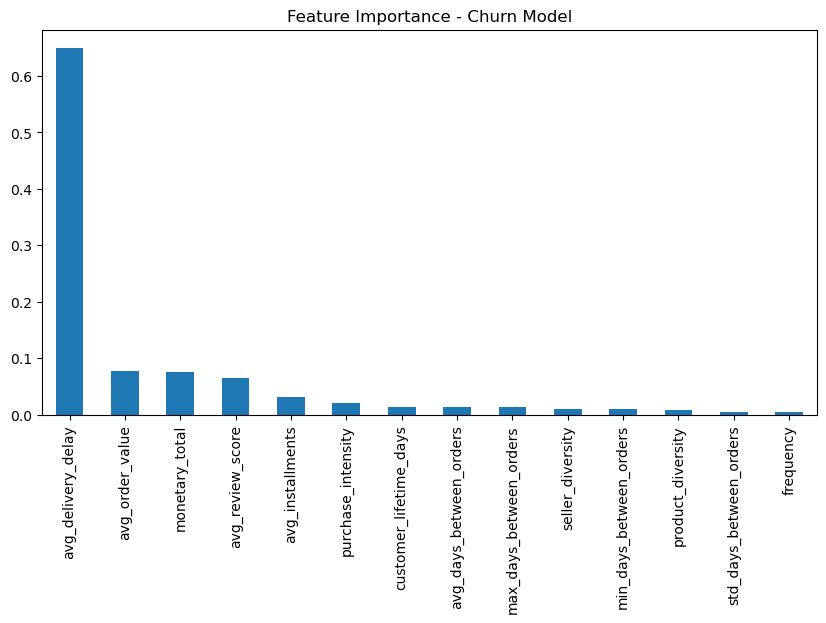

In [24]:
### FEATURE IMPORTANCE



feature_names = X.columns
importances = rf_model.named_steps['model'].feature_importances_

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

feat_imp.plot(kind='bar', figsize=(10,5))
plt.title("Feature Importance - Churn Model")
plt.show()